# Performance Test 

The test will plot the ROC of the algorithms. There are two modes: Full which test both non conjugate and conjugate SCD; limited which test only non conjugate SCD and with limited range.

The algorithm ability to detect cycle frequency under heavy noise will determine its performance. The cycle frequency tested are:

- Full:
    - Rect BPSK: 0.8 Hz Non Conj, -0.8 Hz Conj
    - SRRC QPSK: 0.1 Hz Non Conj, 0.1 Hz Conj
    - GMSK: 0.1 Hz Non Conj, 0.15 Hz Conj

- Limited:
    - Rect BPSK: 0.4 Hz Non Conj
    - SRRC QPSK: 0.1 Hz Non Conj
    - GMSK: 0.1 Hz Non Conj

The signal paramters are 0.1 Hz Symbol Rate, 0.05 Hz CFO, SRRC filter length of 21, SRRC beta of 0.5 and Bandwidth time product of 0.3 for GMSK.

Usage:

```
plot_roc_full(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)

plot_roc_limited(func_lambda, Np=8, no_of_simulation=1000, threshold_resolution=10000, snr=[0], N=2**12, fam=False, L=2, name="roc", save=False)
```

The higher the snr, the easier the test. Same for N (signal length).

In [3]:
import numpy as np
import scf_test.tests as test
from scf_test.algorithm import ssca, fam, fast_sc_wrapper

0dB SNR Score: 4.449/6
-5dB SNR Score: 3.8550000000000004/6
-10dB SNR Score: 3.333/6


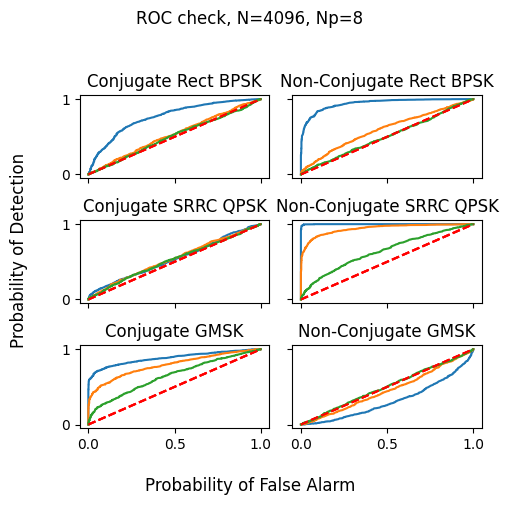

In [ ]:
# For cycle frequency far from 0, it is better to set small Np for high time frequency product -> better resistance against noise

fam_pd, fam_pf, fam_roc_auc, threshold_resolution = test.plot_roc_full(fam, Np=8, L=2, fam=True, snr=[0, -5, -10], name="fam_roc") # fam=True for L paramter

0dB SNR Score: 4.679/6
-5dB SNR Score: 3.951/6
-10dB SNR Score: 3.326/6


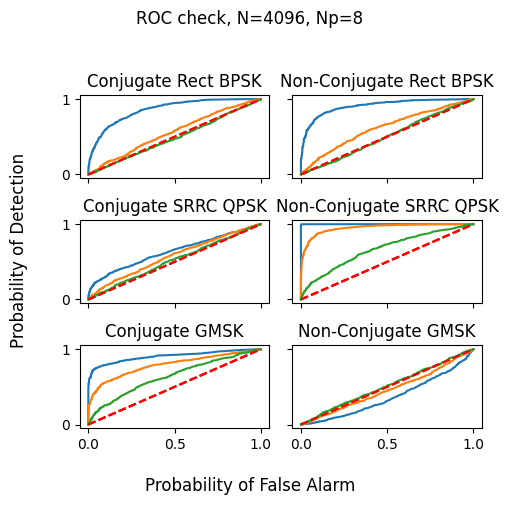

In [8]:
ssca_pd, ssca_pf, ssca_roc_auc, threshold_resolution = test.plot_roc_full(ssca, Np=8, snr=[0, -5, -10], name="ssca_roc") 

For algorithm that only outputs non conjugate SCD and have limited cycle frequency range like FastSC, we have a modified version of the test for them.

0dB SNR Score: 2.308/3
-5dB SNR Score: 2.001/3
-10dB SNR Score: 1.65/3


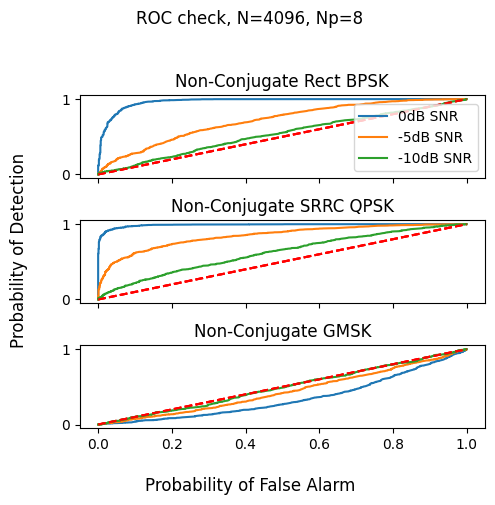

In [10]:
fastsc_pd_limited, fastsc_pf_limited, fastsc_roc_auc_limited, threshold_resolution = test.plot_roc_limited(fast_sc_wrapper, Np=8, snr=[0, -5, -10], name="fastsc_roc") 

0dB SNR Score: 2.108/3
-5dB SNR Score: 1.807/3
-10dB SNR Score: 1.561/3


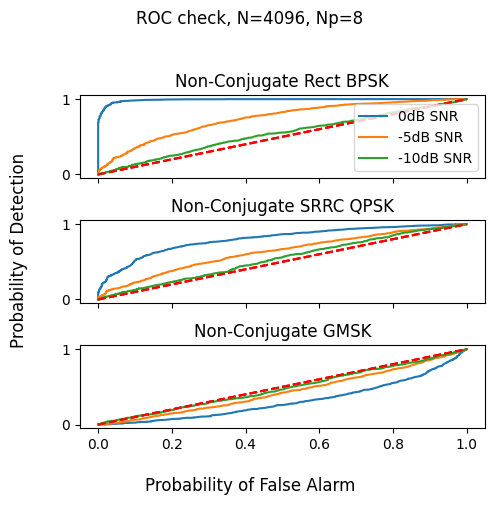

In [11]:
fam_pd_limited, fam_pf_limited, fam_roc_auc_limited, threshold_resolution = test.plot_roc_limited(fam, Np=8, L=2, fam=True, snr=[0, -5, -10], name="fam_roc_limited") # fam=True for L paramter